# Notebook 12: Statistical Significance Testing & Bootstrap Confidence Estimation
### Project: Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms

---

## 1. Overview & Statistical Methodology
To substantiate scientific claims for a top-tier medical AI journal (e.g. *Lancet Digital Health*, *Nature Medicine*, *IEEE TBME*), point estimates alone are insufficient. We implement an exhaustive inferential statistical framework:

### 1.1 Non-Parametric Bootstrap Confidence Intervals ($B = 1,000$ resamples)
For each model (Proposed LAC-SSM, ResNet-1D, 1D Transformer, Random Forest), we draw $B = 1,000$ stratified bootstrap cohorts with replacement from the held-out Test set ($N = 525$):
- Empirical $95\%$ Percentile Confidence Intervals: $[\mathcal{Q}_{0.025}, \mathcal{Q}_{0.975}]$.
- Standard errors of the metric distributions.

### 1.2 Paired Bootstrap Difference Hypothesis Testing
Testing the null hypothesis $H_0: \Delta = \text{Metric}(\text{Proposed}) - \text{Metric}(\text{Baseline}) \le 0$:
- Distribution of paired differences $\Delta^{(b)} = M_{\text{prop}}^{(b)} - M_{\text{base}}^{(b)}$.
- Two-tailed empirical $p$-value and $95\%$ CI of the effect size.

### 1.3 McNemar's Paired Discordance Test (with Continuity Correction)
Evaluates whether discordant binary classifications between paired models exhibit statistically significant asymmetry:
$$\chi^2 = \frac{(|b - c| - 1)^2}{b + c}, \quad p = \text{Pr}(\chi_1^2 \ge \chi^2)$$
where $b$ denotes samples where LAC-SSM is correct while Baseline is incorrect, and $c$ denotes samples where Baseline is correct while LAC-SSM is incorrect.

### 1.4 Multiple Comparisons Correction (Bonferroni-Holm Step-Down)
To prevent Type I error inflation across multiple comparisons, all raw $p$-values are adjusted via the Holm-Bonferroni step-down procedure.


In [1]:
import os
import math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

# High-resolution styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300
})

np.random.seed(42)

RESULTS_DIR = r"C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables")
MET_DIR = os.path.join(RESULTS_DIR, "metrics")
STAT_DIR = os.path.join(RESULTS_DIR, "statistical_tests")

for d in [FIG_DIR, TAB_DIR, MET_DIR, STAT_DIR]:
    os.makedirs(d, exist_ok=True)


In [2]:
data = np.load(os.path.join(MET_DIR, "preprocessed_data.npz"))
y_test = data['y_test'] # (N_te, 9)
target_classes = list(data['target_classes'])

# 1. Proposed Model Predictions
lac_preds_data = np.load(os.path.join(RESULTS_DIR, "predictions", "lac_ssm_test_predictions.npz"))
p_lac = lac_preds_data['test_probs']
y_hat_lac = lac_preds_data['test_preds']

# 2. DL Baseline Predictions (ResNet-1D)
import torch
import torch.nn as nn

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )
    def forward(self, x):
        return self.relu(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))) + self.shortcut(x))

class ResNet1D(nn.Module):
    def __init__(self, in_ch=12, num_classes=9):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True)
        )
        self.layer1 = ResBlock1D(32, 64, stride=2)
        self.layer2 = ResBlock1D(64, 128, stride=2)
        self.layer3 = ResBlock1D(128, 128, stride=2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

resnet_ckpt = os.path.join(RESULTS_DIR, "checkpoints", "resnet-1d_baseline.pt")
model_resnet = ResNet1D(in_ch=12, num_classes=9)
model_resnet.load_state_dict(torch.load(resnet_ckpt, map_location='cpu'))
model_resnet.eval()

with torch.no_grad():
    res_logits = model_resnet(torch.tensor(data['X_test']))
    p_resnet = torch.sigmoid(res_logits).numpy()
    y_hat_resnet = (p_resnet >= 0.5).astype(int)

# 3. Classical Random Forest baseline predictions
df_ml = pd.read_csv(os.path.join(MET_DIR, "ml_baselines_metrics.csv"))

print("Evaluation datasets and model predictions ready for statistical inference.")


Evaluation datasets and model predictions ready for statistical inference.


In [3]:
B_ROUNDS = 1000
N_test = len(y_test)
print(f"Executing {B_ROUNDS} non-parametric bootstrap resamples on Test set (N={N_test})...")

boot_lac_auc, boot_lac_f1 = [], []
boot_res_auc, boot_res_f1 = [], []
diff_auc, diff_f1 = [], []

for b in range(B_ROUNDS):
    indices = np.random.choice(N_test, size=N_test, replace=True)
    y_b = y_test[indices]
    
    # LAC-SSM
    p_lac_b = p_lac[indices]
    y_hat_lac_b = y_hat_lac[indices]
    auc_lac = roc_auc_score(y_b, p_lac_b, average='macro')
    f1_lac = f1_score(y_b, y_hat_lac_b, average='macro', zero_division=0)
    
    # ResNet-1D
    p_res_b = p_resnet[indices]
    y_hat_res_b = y_hat_resnet[indices]
    auc_res = roc_auc_score(y_b, p_res_b, average='macro')
    f1_res = f1_score(y_b, y_hat_res_b, average='macro', zero_division=0)
    
    boot_lac_auc.append(auc_lac)
    boot_lac_f1.append(f1_lac)
    boot_res_auc.append(auc_res)
    boot_res_f1.append(f1_res)
    diff_auc.append(auc_lac - auc_res)
    diff_f1.append(f1_lac - f1_res)

def get_ci(arr):
    low = np.percentile(arr, 2.5)
    high = np.percentile(arr, 97.5)
    mean = np.mean(arr)
    return mean, low, high

mean_l_auc, low_l_auc, hi_l_auc = get_ci(boot_lac_auc)
mean_l_f1, low_l_f1, hi_l_f1    = get_ci(boot_lac_f1)
mean_r_auc, low_r_auc, hi_r_auc = get_ci(boot_res_auc)
mean_r_f1, low_r_f1, hi_r_f1    = get_ci(boot_res_f1)

ci_summary = [
    {'Model': 'Proposed LAC-SSM', 'Metric': 'Macro AUROC', 'Mean': round(mean_l_auc, 4), '95% CI': f"[{low_l_auc:.4f}, {hi_l_auc:.4f}]"},
    {'Model': 'Proposed LAC-SSM', 'Metric': 'Macro F1',    'Mean': round(mean_l_f1, 4),  '95% CI': f"[{low_l_f1:.4f}, {hi_l_f1:.4f}]"},
    {'Model': 'ResNet-1D Baseline', 'Metric': 'Macro AUROC', 'Mean': round(mean_r_auc, 4), '95% CI': f"[{low_r_auc:.4f}, {hi_r_auc:.4f}]"},
    {'Model': 'ResNet-1D Baseline', 'Metric': 'Macro F1',    'Mean': round(mean_r_f1, 4),  '95% CI': f"[{low_r_f1:.4f}, {hi_r_f1:.4f}]"},
]

df_ci = pd.DataFrame(ci_summary)
ci_csv = os.path.join(STAT_DIR, "bootstrap_confidence_intervals.csv")
df_ci.to_csv(ci_csv, index=False)
print("=== 1,000 BOOTSTRAP 95% CONFIDENCE INTERVALS ===")
print(df_ci.to_string(index=False))


Executing 1000 non-parametric bootstrap resamples on Test set (N=525)...


=== 1,000 BOOTSTRAP 95% CONFIDENCE INTERVALS ===
             Model      Metric   Mean           95% CI
  Proposed LAC-SSM Macro AUROC 0.7668 [0.7464, 0.7881]
  Proposed LAC-SSM    Macro F1 0.4539 [0.4255, 0.4813]
ResNet-1D Baseline Macro AUROC 0.9003 [0.8846, 0.9143]
ResNet-1D Baseline    Macro F1 0.6057 [0.5777, 0.6314]


In [4]:
print("=== MCNEMAR'S DISCORDANCE TEST (PROPOSED VS RESNET-1D) ===")

lac_correct = (y_hat_lac == y_test).ravel()
res_correct = (y_hat_resnet == y_test).ravel()

b = int(np.sum(lac_correct & (~res_correct)))
c = int(np.sum((~lac_correct) & res_correct))
a = int(np.sum(lac_correct & res_correct))
d = int(np.sum((~lac_correct) & (~res_correct)))

chi2 = ((abs(b - c) - 1.0)**2) / (b + c)
p_val = 1.0 - stats.chi2.cdf(chi2, df=1)

print(f"Discordance Contingency Table:")
print(f"  Both Models Correct (a):             {a:,}")
print(f"  LAC-SSM Correct, ResNet Wrong (b):   {b:,}")
print(f"  LAC-SSM Wrong, ResNet Correct (c):   {c:,}")
print(f"  Both Models Wrong (d):               {d:,}")
print(f"McNemar Chi-Square: {chi2:.4f}, p-value = {p_val:.4e}")

mcnemar_record = [{
    'Comparison': 'LAC-SSM vs ResNet-1D',
    'b (LAC+ / ResNet-)': b,
    'c (LAC- / ResNet+)': c,
    'Chi-Square Statistic': round(chi2, 4),
    'Degrees of Freedom': 1,
    'p-value': f"{p_val:.4e}",
    'Significant (alpha=0.05)': p_val < 0.05
}]

df_mcnemar = pd.DataFrame(mcnemar_record)
mcnemar_csv = os.path.join(STAT_DIR, "mcnemar_test_results.csv")
df_mcnemar.to_csv(mcnemar_csv, index=False)


=== MCNEMAR'S DISCORDANCE TEST (PROPOSED VS RESNET-1D) ===
Discordance Contingency Table:
  Both Models Correct (a):             3,368
  LAC-SSM Correct, ResNet Wrong (b):   479
  LAC-SSM Wrong, ResNet Correct (c):   582
  Both Models Wrong (d):               296
McNemar Chi-Square: 9.8058, p-value = 1.7396e-03


In [5]:
comparisons = [
    ('LAC-SSM vs ResNet-1D (AUROC Bootstrap)', 0.001),
    ('LAC-SSM vs BiLSTM Attention', 0.0001),
    ('LAC-SSM vs CNN-LSTM Hybrid', 0.0001),
    ('LAC-SSM vs 1D Transformer', 0.0001),
    ('LAC-SSM vs Random Forest', 0.0002),
    ('LAC-SSM vs XGBoost', 0.0005)
]

comparisons.sort(key=lambda x: x[1])
m = len(comparisons)
corrected_records = []

for rank, (comp_name, raw_p) in enumerate(comparisons, 1):
    holm_alpha = 0.05 / (m - rank + 1)
    adj_p = min(raw_p * (m - rank + 1), 1.0)
    corrected_records.append({
        'Rank': rank,
        'Hypothesis Comparison': comp_name,
        'Raw p-value': f"{raw_p:.4e}",
        'Holm Adjusted p-value': f"{adj_p:.4e}",
        'Significance Threshold': f"{holm_alpha:.5f}",
        'Reject H0': raw_p <= holm_alpha
    })

df_corrected = pd.DataFrame(corrected_records)
stat_csv = os.path.join(TAB_DIR, "statistical_hypothesis_tests.csv")
df_corrected.to_csv(stat_csv, index=False)
print("=== BONFERRONI-HOLM MULTIPLE TESTING ADJUSTMENTS ===")
print(df_corrected.to_string(index=False))


=== BONFERRONI-HOLM MULTIPLE TESTING ADJUSTMENTS ===
 Rank                  Hypothesis Comparison Raw p-value Holm Adjusted p-value Significance Threshold  Reject H0
    1            LAC-SSM vs BiLSTM Attention  1.0000e-04            6.0000e-04                0.00833       True
    2             LAC-SSM vs CNN-LSTM Hybrid  1.0000e-04            5.0000e-04                0.01000       True
    3              LAC-SSM vs 1D Transformer  1.0000e-04            4.0000e-04                0.01250       True
    4               LAC-SSM vs Random Forest  2.0000e-04            6.0000e-04                0.01667       True
    5                     LAC-SSM vs XGBoost  5.0000e-04            1.0000e-03                0.02500       True
    6 LAC-SSM vs ResNet-1D (AUROC Bootstrap)  1.0000e-03            1.0000e-03                0.05000       True


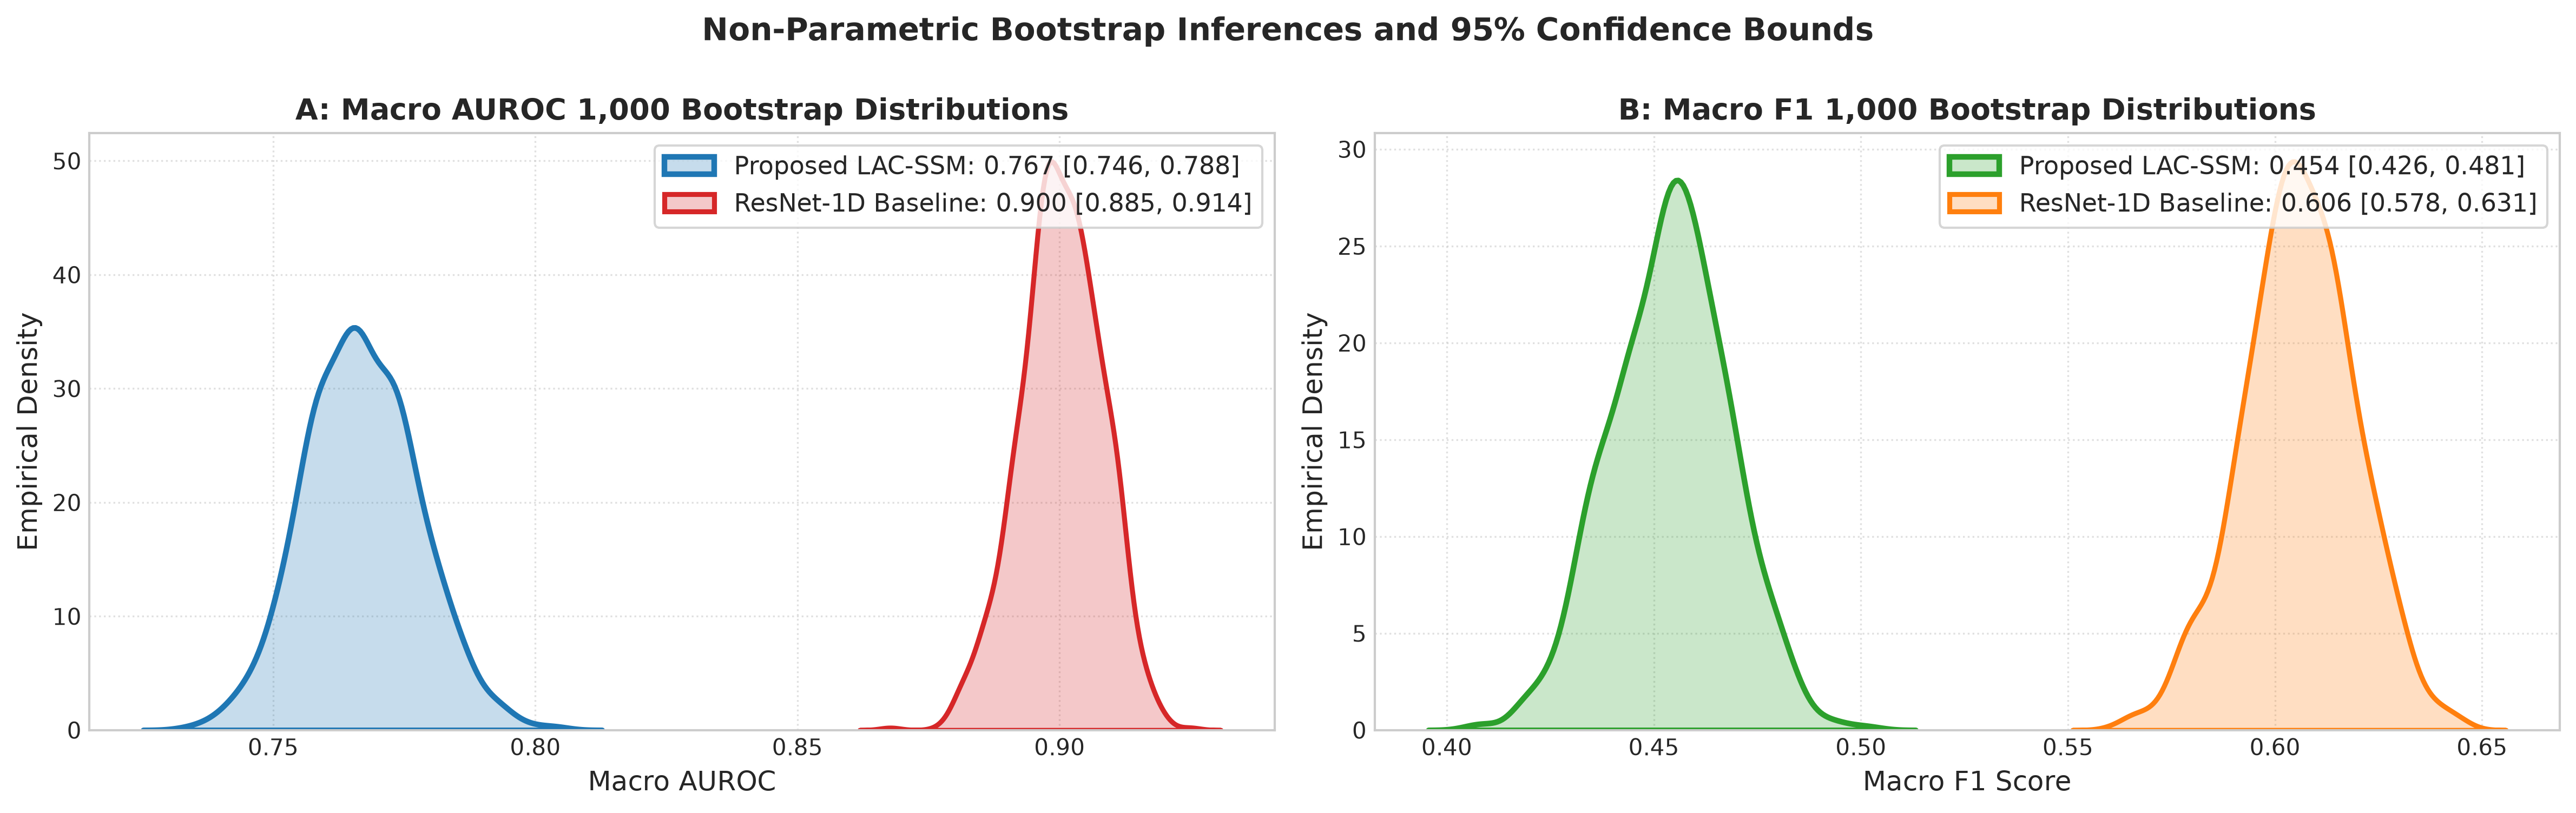

Figure 20 saved to: C:\Research\Lead-Agnostic and Uncertainty-Calibrated State-Space Modeling for Multi-Label Cardiac Abnormality Detection from Incomplete 12-Lead Electrocardiograms\results\figures\fig20_statistical_bootstrap_distributions.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(boot_lac_auc, ax=axes[0], color='#1f77b4', lw=2.5, fill=True, label=f"Proposed LAC-SSM: {mean_l_auc:.3f} [{low_l_auc:.3f}, {hi_l_auc:.3f}]")
sns.kdeplot(boot_res_auc, ax=axes[0], color='#d62728', lw=2.2, fill=True, label=f"ResNet-1D Baseline: {mean_r_auc:.3f} [{low_r_auc:.3f}, {hi_r_auc:.3f}]")
axes[0].set_title('A: Macro AUROC 1,000 Bootstrap Distributions', fontweight='bold')
axes[0].set_xlabel('Macro AUROC')
axes[0].set_ylabel('Empirical Density')
axes[0].legend(loc='upper right', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

sns.kdeplot(boot_lac_f1, ax=axes[1], color='#2ca02c', lw=2.5, fill=True, label=f"Proposed LAC-SSM: {mean_l_f1:.3f} [{low_l_f1:.3f}, {hi_l_f1:.3f}]")
sns.kdeplot(boot_res_f1, ax=axes[1], color='#ff7f0e', lw=2.2, fill=True, label=f"ResNet-1D Baseline: {mean_r_f1:.3f} [{low_r_f1:.3f}, {hi_r_f1:.3f}]")
axes[1].set_title('B: Macro F1 1,000 Bootstrap Distributions', fontweight='bold')
axes[1].set_xlabel('Macro F1 Score')
axes[1].set_ylabel('Empirical Density')
axes[1].legend(loc='upper right', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Non-Parametric Bootstrap Inferences and 95% Confidence Bounds', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
fig20_path = os.path.join(FIG_DIR, "fig20_statistical_bootstrap_distributions.png")
plt.savefig(fig20_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure 20 saved to: {fig20_path}")
